In [2]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [3]:
%autoreload 2

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from estuary.util.img import false_color

In [5]:
# Helper for anchor time localizing to 11am, then UTC, then naive
def set_anchor_time_local_11am(series: pd.Series) -> pd.Series:
    """
    Convert a date-like series to ~11:00 AM America/Los_Angeles,
    then convert to UTC and drop timezone.
    """
    s = pd.to_datetime(series, errors="coerce")
    s = s.dt.tz_localize(None)
    s = s.dt.floor("D") + pd.Timedelta(hours=11)
    s = s.dt.tz_localize("America/Los_Angeles")
    s = s.dt.tz_convert("UTC").dt.tz_localize(None)
    return s

In [6]:
VALID_SITES = list(
    {
        96: ["11482500"],
        12103: ["11481200"],
        92: ["11469000"],
        84: ["11468000"],
        # 77: ["11467553", "11467510"],
        # 72: ["11467000", "11467200"],
        13057: ["11162570"],
        2138: ["11162500"],
        56: ["11161000"],
        57: ["11160000"],
        51: ["11159500"],
        50: ["11152500"],
        48: ["11143250"],
        33: ["11140585"],
        32: ["11136100"],
        31: ["11134000"],
        # 28: ["11120000", "11119940", "11120500", "11120520"],
        # 27: ["11119770", "11119750", "11119745"],
        22: ["11119500"],
        21: ["11118500"],
        # 20: ["11109000", "11113000", "11113500"],
        # 17: ["11046325", "11046360", "11046300"],
        16: ["11046100"],
        15: ["11046000"],
        14: ["11042000"],
        11: ["11023340"],
    }.keys()
)

preds_all = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260305-095554/merged_all_regions_timeseries_preds.csv"
)
preds_all["date"] = pd.to_datetime(preds_all["date"], errors="coerce")
preds_all["acquired"] = pd.to_datetime(preds_all["acquired"], errors="coerce", utc=True)
preds = preds_all[preds_all.y_pred_unsure == 0].copy()
preds = preds[preds.region.isin(VALID_SITES)].copy()

preds["anchor_time"] = set_anchor_time_local_11am(preds.date)

len(preds)
preds.head()

,region,date,y_true,y_true_unsure,acquired,source_tif,y_pred_unsure,y_pred,p_closed,p_open,anchor_time
1,11,2017-02-01,1,0,2017-02-01 17:46:04+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.013752,0.986248,2017-02-01 19:00:00
3,11,2017-02-25,1,0,2017-02-25 17:46:40+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.000013,0.999987,2017-02-25 19:00:00
4,11,2017-03-03,1,0,2017-03-03 17:47:32+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.000008,0.999992,2017-03-03 19:00:00
5,11,2017-03-14,1,0,2017-03-14 17:46:23+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.000116,0.999884,2017-03-14 18:00:00
6,11,2017-04-05,1,0,2017-04-05 17:41:06.666666752+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,0.0,0.992138,0.007862,2017-04-05 18:00:00


In [6]:
base = "/Users/kyledorman/data/results/estuary/train/20260305-095554/"

events = pd.read_csv(
    base + "merged_all_regions_timeseries_preds_closure_events.csv",
    parse_dates=["last_open_time", "first_closed_time", "midpoint_time"],
)

anchors = pd.read_csv(
    base + "merged_all_regions_timeseries_preds_hazard_anchors.csv",
    parse_dates=["anchor_time", "linked_event_time", "linked_event_midpoint_time"],
)

In [42]:
len(anchors.region.unique())

20

In [7]:
print(events["motif_label"].value_counts())
events["include_v1"].value_counts()

motif_label
medium       133
high         113
low           51
ambiguous     14
Name: count, dtype: int64


include_v1
True     246
False     65
Name: count, dtype: int64

In [8]:
len(events)
events[events.include_v1].groupby("region").size().describe()

count    19.000000
mean     12.947368
std       8.878649
min       2.000000
25%       6.500000
50%      10.000000
75%      16.500000
max      37.000000
dtype: float64

In [9]:
events[events.include_v1].groupby("region").size().sort_values()

region
15        2
14        4
32        5
16        6
50        6
51        7
96        7
11        8
33        9
57       10
2138     14
21       15
22       15
31       16
92       17
13057    20
84       20
48       28
56       37
dtype: int64

In [10]:
preds.groupby("region").y_pred.mean().round(2).sort_values()

region
16       0.06
33       0.11
32       0.17
50       0.27
22       0.29
31       0.34
48       0.37
57       0.47
84       0.52
92       0.62
13057    0.63
2138     0.67
56       0.72
96       0.72
14       0.77
21       0.80
15       0.89
51       0.90
11       0.93
12103    1.00
Name: y_pred, dtype: float64

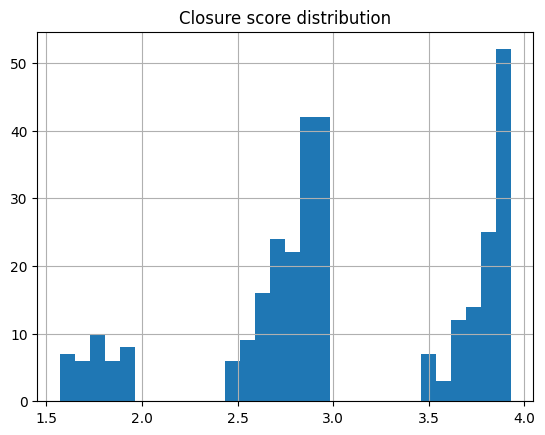

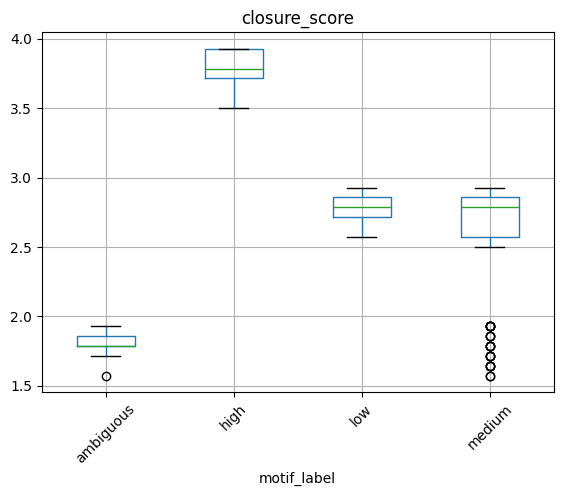

In [11]:
events["closure_score"].hist(bins=30)
plt.title("Closure score distribution")
plt.show()

events.boxplot(column="closure_score", by="motif_label", rot=45)
plt.suptitle("")
plt.show()

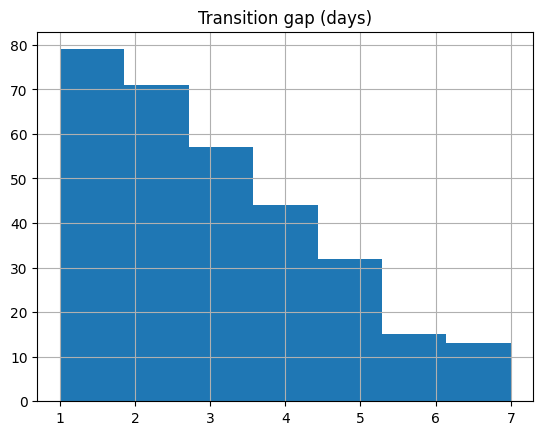

motif_label
ambiguous    2.857143
high         2.946903
low          2.901961
medium       2.917293
Name: transition_gap_days, dtype: float64

In [12]:
events["transition_gap_days"].hist(bins=7)
plt.title("Transition gap (days)")
plt.show()

events.groupby("motif_label")["transition_gap_days"].mean()

In [13]:
anchors.event_y.value_counts()

event_y
0.0    14937
1.0     1480
Name: count, dtype: int64

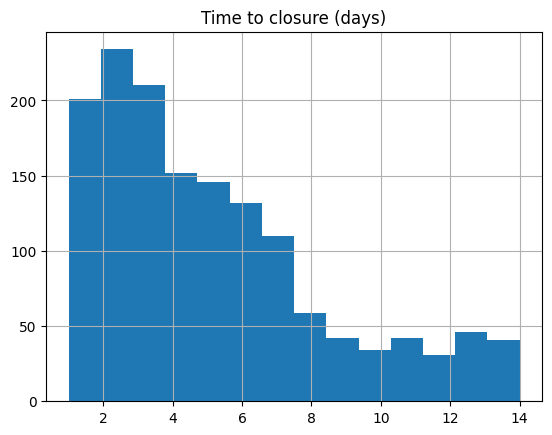

In [14]:
pos = anchors[anchors["event_y"] == 1]

pos["time_to_closure_days"].hist(bins=14)
plt.title("Time to closure (days)")
plt.show()

In [15]:
anchors[anchors["censored"] == False].groupby("region").size()

region
11       1766
14       1496
15       1678
16         64
21       1497
22        369
31        521
32        161
33        163
48        604
50        434
51       1414
56       1484
57        745
84        666
92        702
96        588
2138      717
12103     798
13057     550
dtype: int64

In [16]:
pd.concat(
    [
        preds[(preds.p_closed > 0.9)].groupby("region").size().rename("conf_closed"),
        preds[(preds.p_open > 0.9)].groupby("region").size().rename("conf_open"),
        preds[(preds.p_closed < 0.9) & (preds.p_open < 0.9)]
        .groupby("region")
        .size()
        .rename("unsure"),
    ],
    axis=1,
)

,conf_closed,conf_open,unsure
region,,,
11,68.0,1099,16.0
14,270.0,886,16.0
15,121.0,1004,12.0
16,1139.0,54,22.0
21,223.0,950,40.0
22,760.0,304,43.0
31,674.0,350,23.0
32,795.0,123,93.0
33,943.0,103,11.0


In [17]:
anchors_clean = anchors[anchors["censored"] == False]

anchors_clean.groupby("horizon_days")["event_y"].mean()

horizon_days
3     0.052362
7     0.081513
14    0.122622
Name: event_y, dtype: float64

In [18]:
anchors.groupby("horizon_days")["censored"].mean()

horizon_days
3     0.637215
7     0.474289
14    0.437975
Name: censored, dtype: float64

In [19]:
anchors_pos = anchors_clean[anchors_clean["event_y"] == 1]

anchors_pos.groupby(["region", "linked_event_time", "horizon_days"]).size().describe()

count    653.000000
mean       2.266462
std        1.802195
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max       11.000000
dtype: float64

In [20]:
anchors_clean.groupby("region")["event_y"].mean().sort_values().round(3)

region
12103    0.000
15       0.012
14       0.013
11       0.024
51       0.035
96       0.065
21       0.075
57       0.110
50       0.129
32       0.130
2138     0.132
92       0.134
31       0.134
56       0.154
84       0.191
22       0.195
13057    0.213
48       0.242
33       0.325
16       0.562
Name: event_y, dtype: float64

In [21]:
anchors_clean["region"].value_counts().head(10)

region
11       1766
15       1678
21       1497
14       1496
56       1484
51       1414
12103     798
57        745
2138      717
92        702
Name: count, dtype: int64

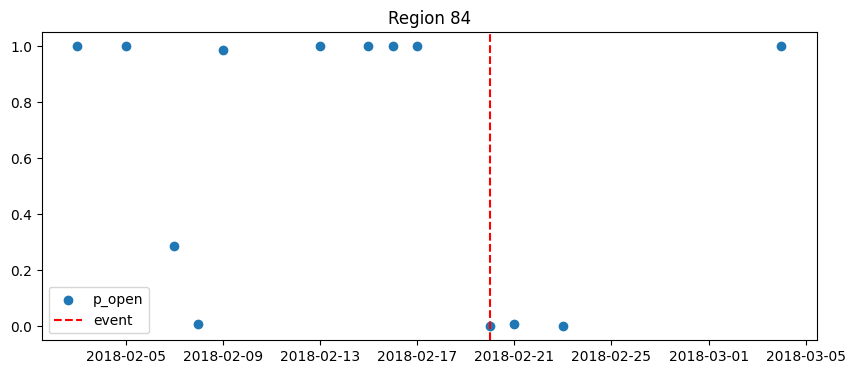

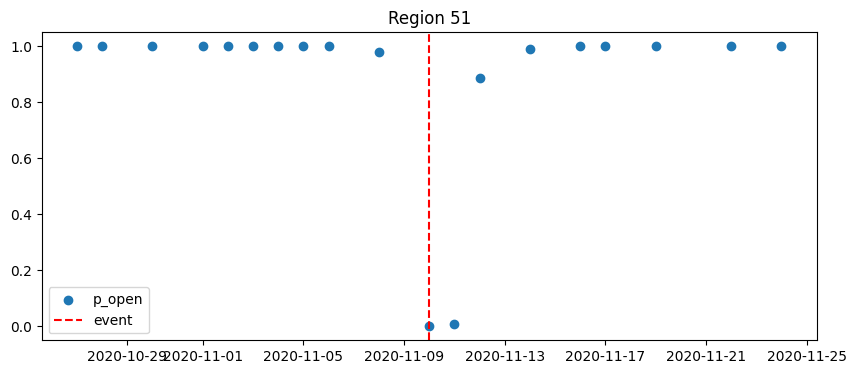

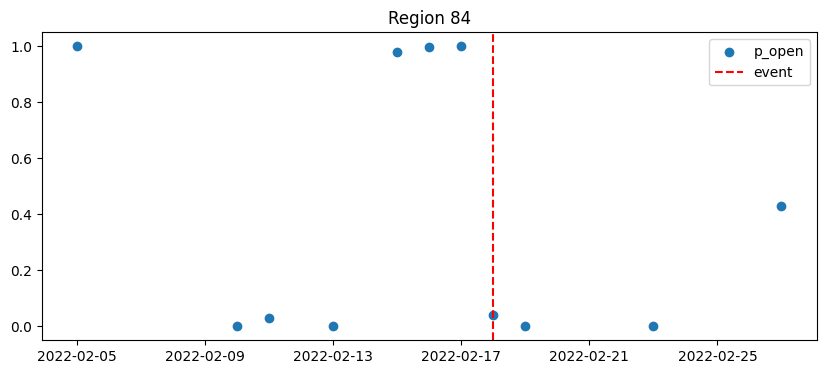

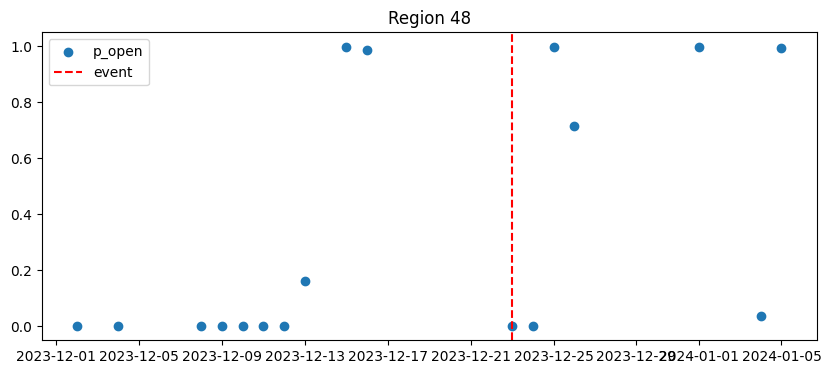

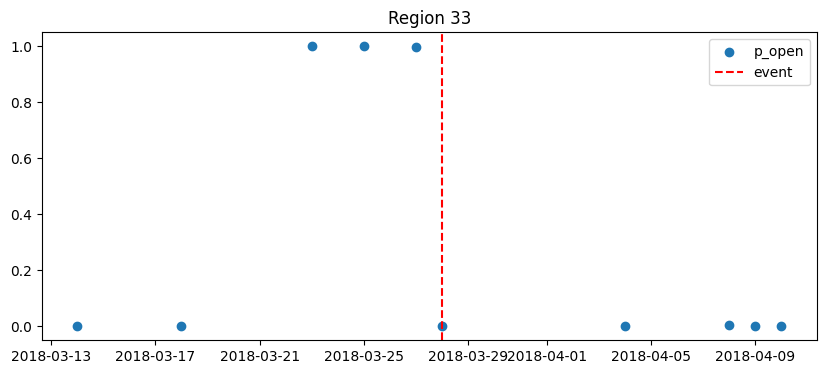

In [22]:
sample_events = events.sample(5, random_state=0)
sample_events


def plot_event(region, event_time, df_raw):
    df_r = df_raw[df_raw["region"] == region].copy()
    df_r = df_r.sort_values("date")

    plt.figure(figsize=(10, 4))
    plt.scatter(df_r["date"], df_r["p_open"], label="p_open")

    plt.axvline(event_time, color="red", linestyle="--", label="event")

    plt.ylim(-0.05, 1.05)
    plt.title(f"Region {region}")
    plt.legend()
    plt.show()


for _, row in sample_events.iterrows():
    start = row.last_open_time - pd.Timedelta("14D")
    end = row.first_closed_time + pd.Timedelta("14D")
    plot_event(row["region"], row["first_closed_time"], preds[preds.date.between(start, end)])

In [23]:
event_time = sample_events.iloc[0]["first_closed_time"]
region = sample_events.iloc[0]["region"]

anchors_sub = anchors_clean[
    (anchors_clean["region"] == region) & (anchors_clean["anchor_time"] < event_time)
].sort_values("anchor_time")

anchors_sub.tail(10)

,region,anchor_index_in_region,anchor_time,horizon_days,event_y,censored,time_to_closure_days,linked_event_time,linked_event_midpoint_time,linked_closure_score,linked_motif_label
23922,84,92,2018-02-13,3,0.0,False,NaN,NaT,NaT,NaN,NaN
23923,84,92,2018-02-13,7,1.0,False,7.0,2018-02-20,2018-02-18 12:00:00,3.785714,high
23924,84,92,2018-02-13,14,1.0,False,7.0,2018-02-20,2018-02-18 12:00:00,3.785714,high
23926,84,93,2018-02-15,7,1.0,False,5.0,2018-02-20,2018-02-18 12:00:00,3.785714,high
23927,84,93,2018-02-15,14,1.0,False,5.0,2018-02-20,2018-02-18 12:00:00,3.785714,high
23929,84,94,2018-02-16,7,1.0,False,4.0,2018-02-20,2018-02-18 12:00:00,3.785714,high
23930,84,94,2018-02-16,14,1.0,False,4.0,2018-02-20,2018-02-18 12:00:00,3.785714,high
23931,84,95,2018-02-17,3,1.0,False,3.0,2018-02-20,2018-02-18 12:00:00,3.785714,high
23932,84,95,2018-02-17,7,1.0,False,3.0,2018-02-20,2018-02-18 12:00:00,3.785714,high
23933,84,95,2018-02-17,14,1.0,False,3.0,2018-02-20,2018-02-18 12:00:00,3.785714,high


In [24]:
features = pd.read_parquet(
    "/Users/kyledorman/data/results/estuary/train/20260305-095554/merged_all_regions_timeseries_preds_hazard_anchors_feature_table.parquet"
)
features.head()

,region,anchor_time,horizon_days,event_y,censored,time_to_closure_days,p_open_anchor,linked_event_time,linked_event_midpoint_time,linked_closure_score,...,tide_coverage_fwd_7d,wave_hs_mean_fwd_14d,wave_hs_max_fwd_14d,wave_hs_energy_fwd_14d,wave_hs_coverage_fwd_14d,streamflow_mean_fwd_14d,streamflow_min_fwd_14d,streamflow_coverage_fwd_14d,tide_range_fwd_14d,tide_coverage_fwd_14d
0,11,2017-02-01 19:00:00,3,NaN,True,NaN,0.986248,NaN,NaN,NaN,...,1.0,1.053997,1.789322,1.183602,1.0,NaN,NaN,0.0,2.220969,1.0
1,11,2017-02-01 19:00:00,7,NaN,True,NaN,0.986248,NaN,NaN,NaN,...,1.0,1.053997,1.789322,1.183602,1.0,NaN,NaN,0.0,2.220969,1.0
2,11,2017-02-01 19:00:00,14,NaN,True,NaN,0.986248,NaN,NaN,NaN,...,1.0,1.053997,1.789322,1.183602,1.0,NaN,NaN,0.0,2.220969,1.0
3,11,2017-02-25 19:00:00,3,NaN,True,NaN,0.999987,NaN,NaN,NaN,...,1.0,0.835759,1.665312,0.776797,1.0,NaN,NaN,0.0,1.967399,1.0
4,11,2017-02-25 19:00:00,7,0.0,False,NaN,0.999987,NaN,NaN,NaN,...,1.0,0.835759,1.665312,0.776797,1.0,NaN,NaN,0.0,1.967399,1.0


In [25]:
features.columns.tolist()

['region',
 'anchor_time',
 'horizon_days',
 'event_y',
 'censored',
 'time_to_closure_days',
 'p_open_anchor',
 'linked_event_time',
 'linked_event_midpoint_time',
 'linked_closure_score',
 'linked_motif_label',
 'wave_hs_mean_prev_7d',
 'wave_hs_max_prev_7d',
 'wave_hs_energy_prev_7d',
 'wave_hs_coverage_prev_7d',
 'streamflow_mean_prev_7d',
 'streamflow_min_prev_7d',
 'streamflow_coverage_prev_7d',
 'tide_range_prev_7d',
 'tide_coverage_prev_7d',
 'wave_hs_mean_fwd_3d',
 'wave_hs_max_fwd_3d',
 'wave_hs_energy_fwd_3d',
 'wave_hs_coverage_fwd_3d',
 'streamflow_mean_fwd_3d',
 'streamflow_min_fwd_3d',
 'streamflow_coverage_fwd_3d',
 'tide_range_fwd_3d',
 'tide_coverage_fwd_3d',
 'wave_hs_mean_fwd_7d',
 'wave_hs_max_fwd_7d',
 'wave_hs_energy_fwd_7d',
 'wave_hs_coverage_fwd_7d',
 'streamflow_mean_fwd_7d',
 'streamflow_min_fwd_7d',
 'streamflow_coverage_fwd_7d',
 'tide_range_fwd_7d',
 'tide_coverage_fwd_7d',
 'wave_hs_mean_fwd_14d',
 'wave_hs_max_fwd_14d',
 'wave_hs_energy_fwd_14d',
 'wave

In [26]:
def validate_wave_columns(df: pd.DataFrame) -> None:
    required = {"site_id", "time", "wave_hs", "wave_flag_primary"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Waves missing required columns: {sorted(missing)}")


def validate_tide_columns(df: pd.DataFrame) -> None:
    required = {"site_id", "time", "tide_elevation"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Tide missing required columns: {sorted(missing)}")


def validate_flow_columns(df: pd.DataFrame) -> None:
    required = {
        "site_id",
        "date_time",
        "variable_code",
        "value",
        "no_data_value",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Streamflow missing required columns: {sorted(missing)}")


# =========================
# CDIP wave QC filter
# =========================


def filter_cdip_wave_qc(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply a conservative CDIP QC filter.

    CDIP primary QC flags follow the UNESCO/IOC convention:
    1 = good
    2 = not_evaluated
    3 = questionable
    4 = bad
    9 = missing

    For a first pass, keep 1/2/3 and drop 4/9.
    We do not filter on the secondary flag here because its meanings can vary
    by product, while the primary flag consistently identifies bad/missing data.
    """
    out = df.copy()
    out["wave_flag_primary"] = pd.to_numeric(out["wave_flag_primary"], errors="coerce")
    out = out[out["wave_flag_primary"].isin([1, 2, 3])].copy()
    return out


def filter_usgs_iv_qc(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply a conservative USGS instantaneous-values filter.

    Rules for v1:
    - keep discharge only: variable_code == "00060"
    - if an approval_status column is present, keep only Approved rows
    - otherwise, fall back to qualifier_codes and keep rows that appear approved
      (contain "A") while dropping rows that appear provisional (contain "P")

    This fallback exists because some exported IV tables expose approval through
    qualifier codes rather than a separate approval_status column.
    """
    out = df.copy()

    out["variable_code"] = out["variable_code"].astype(str)
    out = out[out["variable_code"] == "00060"].copy()

    if "approval_status" in out.columns:
        approval = out["approval_status"].astype(str).str.strip().str.lower()
        out = out[approval == "approved"].copy()
    else:
        qualifier = out.get("qualifier_codes", pd.Series("", index=out.index))
        qualifier = qualifier.fillna("").astype(str).str.upper()
        has_a = qualifier.str.contains(r"(?:^|\\b|,|;)A(?:\\b|,|;|$)", regex=True)
        has_p = qualifier.str.contains(r"(?:^|\\b|,|;)P(?:\\b|,|;|$)", regex=True)
        out = out[has_a & ~has_p].copy()

    return out


def prepare_waves(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize waves table and apply a conservative CDIP QC filter.
    """
    validate_wave_columns(df)

    out = df.copy()
    out = filter_cdip_wave_qc(out)
    out = out.rename(columns={"site_id": "region"})
    out["time"] = pd.to_datetime(out["time"], errors="coerce", utc=True).dt.tz_localize(None)
    out["wave_hs"] = pd.to_numeric(out["wave_hs"], errors="coerce")
    out = out[out["wave_hs"] >= 0].copy()

    out = out.dropna(subset=["region", "time", "wave_hs"]).copy()
    out = out.sort_values(["region", "time"]).reset_index(drop=True)

    return out[["region", "time", "wave_hs", "wave_flag_primary"]]


def prepare_tide(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize tide table.
    """
    validate_tide_columns(df)

    out = df.copy()
    out = out.rename(columns={"site_id": "region", "tide_elevation": "tide"})
    out["time"] = pd.to_datetime(out["time"], errors="coerce", utc=True).dt.tz_localize(None)
    out["tide"] = pd.to_numeric(out["tide"], errors="coerce")

    out = out.dropna(subset=["region", "time", "tide"]).copy()
    out = out.sort_values(["region", "time"]).reset_index(drop=True)

    return out[["region", "time", "tide"]]


def prepare_streamflow(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize USGS instantaneous streamflow and apply conservative IV filtering.
    """
    validate_flow_columns(df)

    out = df.copy()
    out = filter_usgs_iv_qc(out)
    out = out.rename(columns={"site_id": "region", "date_time": "time", "value": "streamflow"})

    out["time"] = pd.to_datetime(out["time"], errors="coerce", utc=True).dt.tz_localize(None)
    out["streamflow"] = pd.to_numeric(out["streamflow"], errors="coerce")

    out["no_data_value"] = pd.to_numeric(out["no_data_value"], errors="coerce")

    # Drop rows where the streamflow equals the USGS no-data sentinel value.
    has_no_data = out["no_data_value"].notna()
    out = out.loc[~(has_no_data & (out["streamflow"] == out["no_data_value"]))].copy()

    out = out.dropna(subset=["region", "time", "streamflow"]).copy()
    out = out.sort_values(["region", "time"]).reset_index(drop=True)

    return out[["region", "time", "streamflow", "variable_code"]]

In [28]:
waves_path = "/Volumes/x10pro/estuary/drivers_data/cdip_waves.parquet"
tide_path = "/Volumes/x10pro/estuary/drivers_data/fes2022_tides.parquet"
streamflow_path = "/Volumes/x10pro/estuary/drivers_data/usgs_data_iv.parquet"

waves_df = pd.read_parquet(waves_path)
tide_df = pd.read_parquet(tide_path)
streamflow_df = pd.read_parquet(streamflow_path)

waves = prepare_waves(waves_df)
waves = waves[waves.region.isin(VALID_SITES)].copy()
tide = prepare_tide(tide_df)
tide = tide[tide.region.isin(VALID_SITES)].copy()
flow = prepare_streamflow(streamflow_df)
flow = flow[flow.region.isin(VALID_SITES)].copy()

In [40]:
waves_df.wave_tp.min()

np.float32(2.5)

In [41]:
waves.head()

,region,time,wave_hs,wave_flag_primary
0,11,2017-01-01 00:00:00,0.766374,1.0
1,11,2017-01-01 01:00:00,0.800425,1.0
2,11,2017-01-01 02:00:00,0.852419,1.0
3,11,2017-01-01 03:00:00,0.922074,1.0
4,11,2017-01-01 04:00:00,1.010671,1.0


In [43]:
flow[flow.streamflow > 0].min()

region                            11
time             2018-01-01 08:00:00
streamflow                      0.01
variable_code                  00060
dtype: object

In [29]:
import matplotlib.pyplot as plt
import pandas as pd


def _minmax_norm(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    if s.notna().sum() == 0:
        return s
    smin = s.min()
    smax = s.max()
    if pd.isna(smin) or pd.isna(smax):
        return s
    if smax == smin:
        return pd.Series(np.where(s.notna(), 0.5, np.nan), index=s.index)
    return (s - smin) / (smax - smin)


def plot_single_feature_example(
    features: pd.DataFrame,
    preds: pd.DataFrame,
    waves: pd.DataFrame,
    tide: pd.DataFrame,
    streamflow: pd.DataFrame,
    row_idx: int | None = None,
    region: int | str | None = None,
    anchor_time: str | pd.Timestamp | None = None,
    only_uncensored: bool = False,
    only_event: bool | None = None,
    days_before: int = 14,
    days_after: int = 14,
):
    """
    Plot one example from the feature table with normalized p_open, wave_hs,
    tide, and streamflow over a +/- window around the anchor.

    Selection priority:
    1. row_idx if provided
    2. exact (region, anchor_time) if provided
    3. first row after optional filtering
    """

    feat = features.copy()
    feat["anchor_time"] = pd.to_datetime(feat["anchor_time"], errors="coerce")

    if "linked_event_time" in feat.columns:
        feat["linked_event_time"] = pd.to_datetime(feat["linked_event_time"], errors="coerce")

    if only_uncensored:
        feat = feat[feat["censored"] == False].copy()

    if only_event is True:
        feat = feat[feat["event_y"] == 1].copy()
    elif only_event is False:
        feat = feat[feat["event_y"] == 0].copy()

    if region is not None:
        feat = feat[feat["region"] == region].copy()

    if row_idx is not None:
        assert region is None
        assert only_event is None
        assert not only_uncensored

        row = feat.iloc[row_idx].copy()
        row["anchor_time"] = pd.to_datetime(row["anchor_time"], errors="coerce")
        if "linked_event_time" in row.index:
            row["linked_event_time"] = pd.to_datetime(row["linked_event_time"], errors="coerce")
    elif anchor_time is not None:
        anchor_time = pd.to_datetime(anchor_time)
        m = feat["anchor_time"] == anchor_time
        if m.sum() == 0:
            raise ValueError("No matching row found for the provided region and anchor_time.")
        row = feat.loc[m].iloc[0].copy()
    else:
        if len(feat) == 0:
            raise ValueError("No rows available after filtering.")
        row = feat.sample(1, random_state=None).iloc[0].copy()

    region_val = row["region"]
    anchor = pd.to_datetime(row["anchor_time"])
    event_time = (
        pd.to_datetime(row["linked_event_time"], errors="coerce")
        if "linked_event_time" in row.index
        else pd.NaT
    )

    t0 = anchor - pd.Timedelta(days=days_before)
    t1 = anchor + pd.Timedelta(days=days_after)

    # Predictions
    preds_sub = preds.copy()
    preds_sub["date"] = pd.to_datetime(preds_sub["date"], errors="coerce")
    preds_sub = preds_sub[
        (preds_sub["region"] == region_val) & (preds_sub["date"] >= t0) & (preds_sub["date"] <= t1)
    ].copy()
    preds_sub = preds_sub.sort_values("date")

    # Waves
    waves_sub = waves[
        (waves["region"] == region_val) & (waves["time"] >= t0) & (waves["time"] <= t1)
    ].copy()
    waves_sub = waves_sub.sort_values("time")
    waves_sub["wave_hs_norm"] = _minmax_norm(waves_sub["wave_hs"])

    # Tide
    tide_sub = tide[
        (tide["region"] == region_val) & (tide["time"] >= t0) & (tide["time"] <= t1)
    ].copy()
    tide_sub = tide_sub.sort_values("time")
    tide_sub["tide_norm"] = _minmax_norm(tide_sub["tide"])

    # Streamflow
    flow_sub = streamflow[
        (streamflow["region"] == region_val)
        & (streamflow["time"] >= t0)
        & (streamflow["time"] <= t1)
    ].copy()
    flow_sub = flow_sub.sort_values("time")
    flow_sub["streamflow_norm"] = _minmax_norm(flow_sub["streamflow"])

    fig, ax = plt.subplots(figsize=(14, 6))

    # Lines
    if len(preds_sub):
        # ax.plot(preds_sub["anchor_time"], preds_sub["p_open"], label="p_open (norm)")
        ax.scatter(preds_sub["anchor_time"], preds_sub["p_open"], s=25, label="p_open")

    if len(waves_sub):
        ax.plot(waves_sub["time"], waves_sub["wave_hs_norm"], label="wave_hs (norm)", alpha=0.9)
        # ax.scatter(waves_sub["time"], waves_sub["wave_hs_norm"], s=8, alpha=0.5)

    if len(tide_sub):
        ax.plot(tide_sub["time"], tide_sub["tide_norm"], label="tide (norm)", alpha=0.8)
        # ax.scatter(tide_sub["time"], tide_sub["tide_norm"], s=6, alpha=0.35)

    if len(flow_sub):
        ax.plot(flow_sub["time"], flow_sub["streamflow_norm"], label="streamflow (norm)", alpha=0.9)
        # ax.scatter(flow_sub["time"], flow_sub["streamflow_norm"], s=8, alpha=0.5)

    # Vertical markers
    ax.axvline(anchor, linestyle="--", linewidth=1.5, label="anchor_time")

    if pd.notna(event_time):
        ax.axvline(
            event_time, linestyle="--", linewidth=1.5, label="linked_event_time", color="red"
        )

    title = (
        f"Region {region_val} | anchor={anchor} | "
        f"horizon={row.get('horizon_days', np.nan)} | "
        f"event_y={row.get('event_y', np.nan)} | "
        f"censored={row.get('censored', np.nan)}"
    )
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("Normalized value")
    ax.legend(loc="upper left")
    plt.show()

    return row

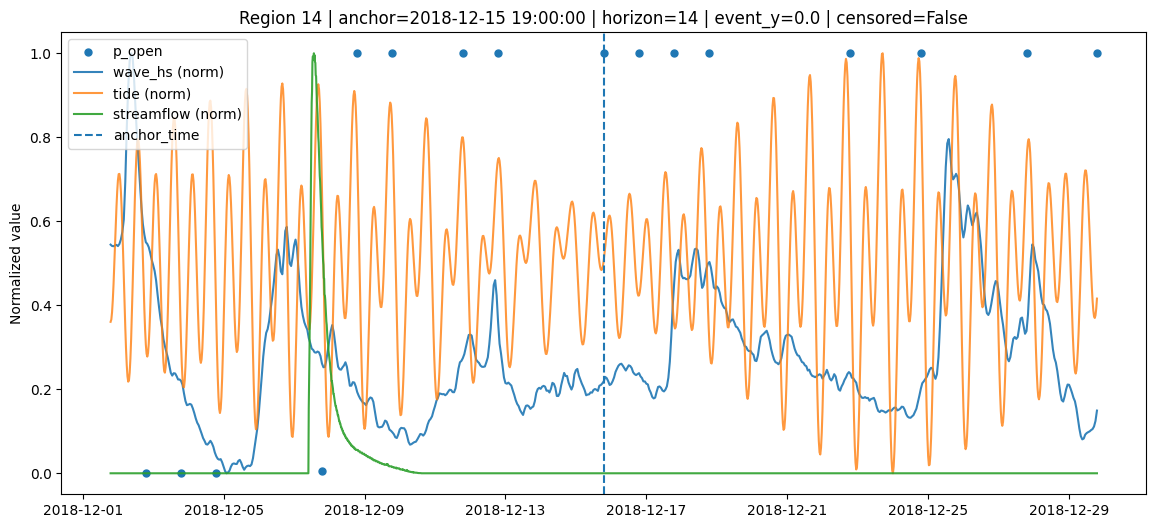

In [158]:
_ = plot_single_feature_example(
    features=features,  # [(features.horizon_days == 14) & (features.streamflow_coverage_fwd_14d >= 0.9)].copy(),
    tide=tide,
    streamflow=flow,
    waves=waves,
    preds=preds,
    # region=11,
    # only_uncensored=True,
    # only_event=False,
    row_idx=3482,
)

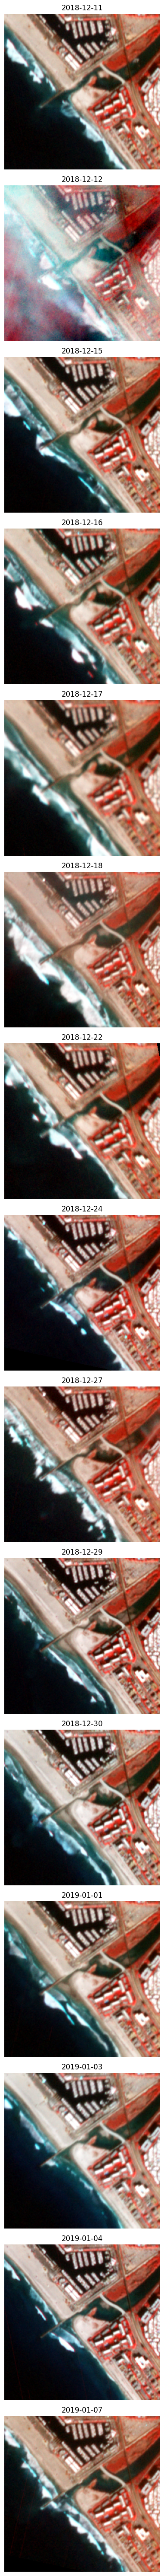

In [157]:
row = features.iloc[3497]
time = pd.Timestamp(row.anchor_time).tz_localize("UTC")
window_preds = preds[
    (preds.acquired.between(time - pd.Timedelta("14D"), time + pd.Timedelta("14D")))
    & (preds.region == row.region)
].reset_index(drop=True)
fig, axes = plt.subplots(nrows=len(window_preds), ncols=1, figsize=(4, 4 * len(window_preds)))

for ax, (_, r) in zip(axes, window_preds.iterrows()):
    with rasterio.open(r.source_tif) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(r.acquired.date())
fig.tight_layout()
plt.show()

In [130]:
streamflow = pd.read_parquet(streamflow_path)
streamflow["date_time"] = pd.to_datetime(
    streamflow["date_time"], errors="coerce", utc=True
).dt.tz_localize(None)
streamflow = streamflow.dropna(subset=["date_time"])
streamflow = streamflow[streamflow.variable_code == "00060"].copy()
streamflow = streamflow.sort_values(by=["gauge_id", "date_time"]).reset_index(drop=True)
streamflow.head()

,site_id,gauge_id,site_code,site_name,network,huc_cd,data_type,date_time,value,qualifier_codes,qualifier_codes_available,variable_code,variable_name,statistic_code,unit,unit_name,no_data_value,method_description,latitude,longitude
0,11,11023340,11023340,LOS PENASQUITOS C NR POWAY CA,NWIS,18070304,iv,2018-01-01 08:00:00,2.26,A,"e,A",00060,"Streamflow, ft&#179;/s",NaN,ft3/s,None,-999999.0,,32.943101,-117.1217
1,11,11023340,11023340,LOS PENASQUITOS C NR POWAY CA,NWIS,18070304,iv,2018-01-01 08:15:00,2.26,A,"e,A",00060,"Streamflow, ft&#179;/s",NaN,ft3/s,None,-999999.0,,32.943101,-117.1217
2,11,11023340,11023340,LOS PENASQUITOS C NR POWAY CA,NWIS,18070304,iv,2018-01-01 08:30:00,2.33,A,"e,A",00060,"Streamflow, ft&#179;/s",NaN,ft3/s,None,-999999.0,,32.943101,-117.1217
3,11,11023340,11023340,LOS PENASQUITOS C NR POWAY CA,NWIS,18070304,iv,2018-01-01 08:45:00,2.33,A,"e,A",00060,"Streamflow, ft&#179;/s",NaN,ft3/s,None,-999999.0,,32.943101,-117.1217
4,11,11023340,11023340,LOS PENASQUITOS C NR POWAY CA,NWIS,18070304,iv,2018-01-01 09:00:00,2.33,A,"e,A",00060,"Streamflow, ft&#179;/s",NaN,ft3/s,None,-999999.0,,32.943101,-117.1217


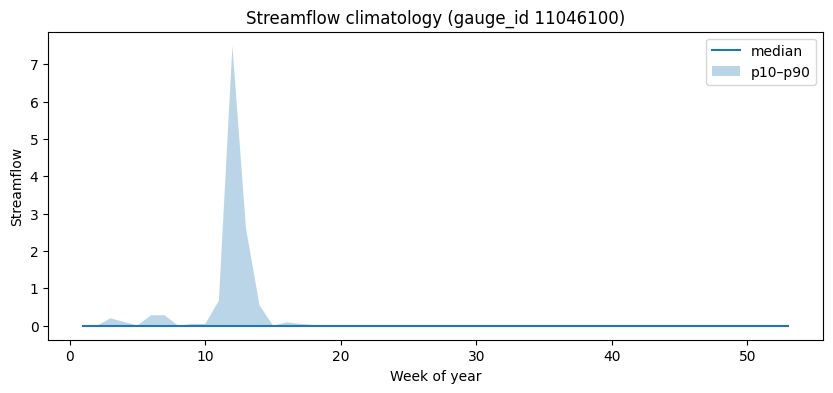

In [169]:
flow_clim = streamflow.copy()

flow_clim["time"] = pd.to_datetime(flow_clim["date_time"])
flow_clim["streamflow"] = flow_clim.value
flow_clim["week"] = flow_clim["time"].dt.isocalendar().week
flow_clim["year"] = flow_clim["time"].dt.year

weekly_stats = (
    flow_clim.groupby(["gauge_id", "week"])["streamflow"]
    .quantile([0.1, 0.5, 0.9])
    .unstack()
    .rename(columns={0.1: "p10", 0.5: "p50", 0.9: "p90"})
    .reset_index()
)

import matplotlib.pyplot as plt


def plot_streamflow_climatology(gauge_id):
    sub = weekly_stats[weekly_stats["gauge_id"] == gauge_id]

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(sub["week"], sub["p50"], label="median")
    ax.fill_between(sub["week"], sub["p10"], sub["p90"], alpha=0.3, label="p10–p90")

    ax.set_title(f"Streamflow climatology (gauge_id {gauge_id})")
    ax.set_xlabel("Week of year")
    ax.set_ylabel("Streamflow")
    ax.legend()

    plt.show()


plot_streamflow_climatology("11046100")

In [33]:
features[[c for c in features.columns if "coverage" in c]].describe()

,wave_hs_coverage_prev_7d,streamflow_coverage_prev_7d,tide_coverage_prev_7d,wave_hs_coverage_fwd_3d,streamflow_coverage_fwd_3d,tide_coverage_fwd_3d,wave_hs_coverage_fwd_7d,streamflow_coverage_fwd_7d,tide_coverage_fwd_7d,wave_hs_coverage_fwd_14d,streamflow_coverage_fwd_14d,tide_coverage_fwd_14d
count,33954.000000,33954.000000,33954.000000,33954.000000,33954.000000,33954.000000,33954.000000,33954.000000,33954.000000,33954.000000,33954.000000,33954.000000
mean,0.883682,0.877021,0.884221,0.881795,0.874652,0.882326,0.881550,0.874273,0.882093,0.881173,0.875018,0.881686
std,0.319835,0.688822,0.319284,0.322568,0.694412,0.321940,0.322908,0.690788,0.322284,0.322960,0.687289,0.322535
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.587798,1.000000,1.000000,0.527778,1.000000,1.000000,0.561012,1.000000,1.000000,0.592262,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,3.000000,1.000000,1.000000,3.000000,1.000000,1.000000,3.000000,1.000000,1.000000,3.000000,1.000000


In [34]:
features.isna().mean().sort_values(ascending=False).head(20)

time_to_closure_days          0.956412
linked_event_time             0.956412
linked_event_midpoint_time    0.956412
linked_closure_score          0.956412
linked_motif_label            0.956412
event_y                       0.516493
streamflow_min_fwd_3d         0.230960
streamflow_mean_fwd_3d        0.230960
streamflow_min_fwd_7d         0.226719
streamflow_mean_fwd_7d        0.226719
streamflow_min_prev_7d        0.221506
streamflow_mean_prev_7d       0.221506
streamflow_mean_fwd_14d       0.219562
streamflow_min_fwd_14d        0.219562
wave_hs_max_fwd_3d            0.117512
wave_hs_mean_fwd_3d           0.117512
wave_hs_energy_fwd_7d         0.117512
wave_hs_energy_fwd_3d         0.117512
wave_hs_mean_fwd_7d           0.117512
wave_hs_max_fwd_7d            0.117512
dtype: float64

In [67]:
features[features["streamflow_mean_fwd_7d"] < 0.1]

,region,anchor_time,horizon_days,event_y,censored,time_to_closure_days,p_open_anchor,linked_event_time,linked_event_midpoint_time,linked_closure_score,...,tide_coverage_fwd_7d,wave_hs_mean_fwd_14d,wave_hs_max_fwd_14d,wave_hs_energy_fwd_14d,wave_hs_coverage_fwd_14d,streamflow_mean_fwd_14d,streamflow_min_fwd_14d,streamflow_coverage_fwd_14d,tide_range_fwd_14d,tide_coverage_fwd_14d
3735,14,2019-07-23 18:00:00,3,0.0,False,NaN,0.999986,NaN,NaN,NaN,...,1.0,0.849860,1.304459,0.751099,1.0,0.035714,0.03,0.005208,2.372709,1.0
3736,14,2019-07-23 18:00:00,7,0.0,False,NaN,0.999986,NaN,NaN,NaN,...,1.0,0.849860,1.304459,0.751099,1.0,0.035714,0.03,0.005208,2.372709,1.0
3737,14,2019-07-23 18:00:00,14,0.0,False,NaN,0.999986,NaN,NaN,NaN,...,1.0,0.849860,1.304459,0.751099,1.0,0.035714,0.03,0.005208,2.372709,1.0
4281,14,2020-09-20 18:00:00,3,NaN,True,NaN,0.999990,NaN,NaN,NaN,...,1.0,0.819625,1.292777,0.700301,1.0,0.089467,0.04,0.363095,2.011750,1.0
4282,14,2020-09-20 18:00:00,7,0.0,False,NaN,0.999990,NaN,NaN,NaN,...,1.0,0.819625,1.292777,0.700301,1.0,0.089467,0.04,0.363095,2.011750,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12418,22,2022-03-29 18:00:00,7,1.0,False,6.0,0.999343,2022-04-04 00:00:00,2022-04-01 00:00:00,2.571429,...,1.0,0.686091,1.381862,0.508578,1.0,0.059231,0.01,0.048363,2.012486,1.0
12419,22,2022-03-29 18:00:00,14,1.0,False,6.0,0.999343,2022-04-04 00:00:00,2022-04-01 00:00:00,2.571429,...,1.0,0.686091,1.381862,0.508578,1.0,0.059231,0.01,0.048363,2.012486,1.0
14424,33,2023-02-02 19:00:00,3,0.0,False,NaN,0.999967,NaN,NaN,NaN,...,1.0,2.497381,4.515443,7.005891,1.0,0.097143,0.02,0.005208,1.859072,1.0
14425,33,2023-02-02 19:00:00,7,NaN,True,NaN,0.999967,NaN,NaN,NaN,...,1.0,2.497381,4.515443,7.005891,1.0,0.097143,0.02,0.005208,1.859072,1.0


<Axes: >

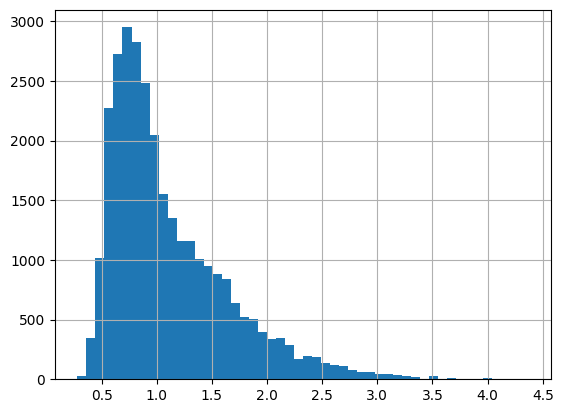

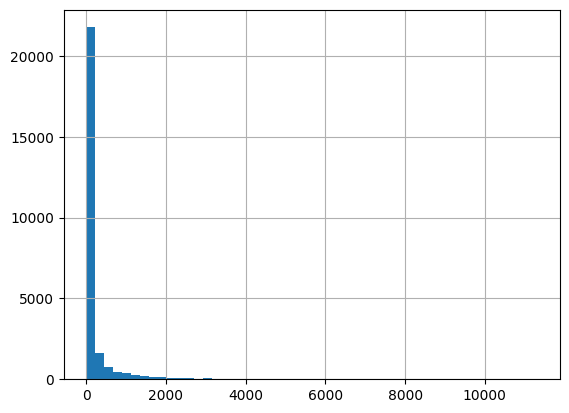

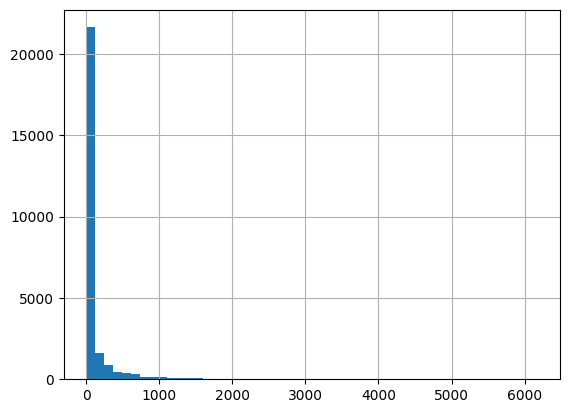

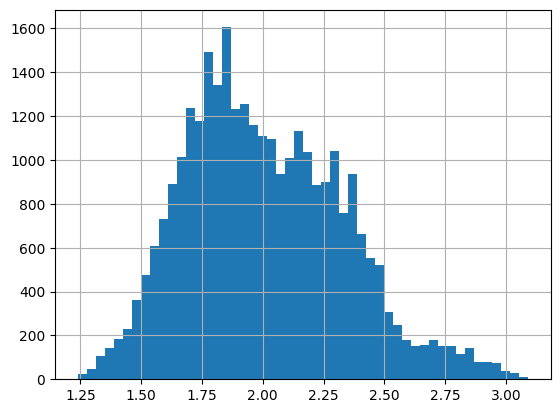

In [35]:
plt.figure()
features["wave_hs_mean_fwd_7d"].hist(bins=50)
plt.figure()
features["streamflow_mean_fwd_7d"].hist(bins=50)
plt.figure()
features["streamflow_min_fwd_7d"].hist(bins=50)
plt.figure()
features["tide_range_fwd_7d"].hist(bins=50)

In [36]:
df = features[features["censored"] == False]

df.groupby("event_y")[
    ["wave_hs_max_fwd_7d", "streamflow_mean_fwd_7d", "streamflow_min_fwd_7d", "tide_range_fwd_7d"]
].mean()

,wave_hs_max_fwd_7d,streamflow_mean_fwd_7d,streamflow_min_fwd_7d,tide_range_fwd_7d
event_y,,,,
0.0,1.752752,185.952796,109.103010,1.993840
1.0,1.940393,30.622836,24.132015,1.979723


In [44]:
pos = df[df["event_y"] == 1]

pos.groupby("time_to_closure_days").wave_hs_max_fwd_7d.mean()

time_to_closure_days
1.0     1.921920
2.0     1.858237
3.0     1.788796
4.0     2.201702
5.0     1.828947
6.0     2.307947
7.0     1.948524
8.0     1.989104
9.0     2.195942
10.0    1.947692
11.0    1.762750
12.0    1.798094
13.0    1.814737
14.0    1.722909
Name: wave_hs_max_fwd_7d, dtype: float64

In [38]:
df.groupby("region")["event_y"].mean().describe()

count    20.000000
mean      0.143819
std       0.130081
min       0.000000
25%       0.057310
50%       0.131466
75%       0.191799
max       0.562500
Name: event_y, dtype: float64

In [39]:
df.groupby("region")["wave_hs_mean_fwd_7d"].mean().describe()

count    20.000000
mean      1.248726
std       0.495729
min       0.604647
25%       0.819802
50%       1.154934
75%       1.632169
max       2.062291
Name: wave_hs_mean_fwd_7d, dtype: float64

In [40]:
(features["anchor_time"].dt.hour).value_counts()

anchor_time
18    21018
19    12936
Name: count, dtype: int64

In [41]:
features.sort_values("wave_hs_mean_fwd_7d", ascending=False).head()

,region,anchor_time,horizon_days,event_y,censored,time_to_closure_days,p_open_anchor,linked_event_time,linked_event_midpoint_time,linked_closure_score,...,tide_coverage_fwd_7d,wave_hs_mean_fwd_14d,wave_hs_max_fwd_14d,wave_hs_energy_fwd_14d,wave_hs_coverage_fwd_14d,streamflow_mean_fwd_14d,streamflow_min_fwd_14d,streamflow_coverage_fwd_14d,tide_range_fwd_14d,tide_coverage_fwd_14d
13519,31,2023-12-23 19:00:00,7,0.0,False,NaN,0.999974,NaN,NaN,NaN,...,1.0,3.980974,10.411388,18.229208,1.0,36.925690,23.6,0.970238,2.090078,1.0
13518,31,2023-12-23 19:00:00,3,NaN,True,NaN,0.999974,NaN,NaN,NaN,...,1.0,3.980974,10.411388,18.229208,1.0,36.925690,23.6,0.970238,2.090078,1.0
13520,31,2023-12-23 19:00:00,14,1.0,False,13.0,0.999974,2024-01-05 00:00:00,2024-01-03 00:00:00,3.714286,...,1.0,3.980974,10.411388,18.229208,1.0,36.925690,23.6,0.970238,2.090078,1.0
13302,31,2023-01-05 19:00:00,3,NaN,True,NaN,0.999993,NaN,NaN,NaN,...,1.0,4.134988,8.714699,19.327383,1.0,2714.523065,221.0,1.000000,2.023166,1.0
13303,31,2023-01-05 19:00:00,7,NaN,True,NaN,0.999993,NaN,NaN,NaN,...,1.0,4.134988,8.714699,19.327383,1.0,2714.523065,221.0,1.000000,2.023166,1.0


In [42]:
features.sort_values("streamflow_min_fwd_7d").head()

,region,anchor_time,horizon_days,event_y,censored,time_to_closure_days,p_open_anchor,linked_event_time,linked_event_midpoint_time,linked_closure_score,...,tide_coverage_fwd_7d,wave_hs_mean_fwd_14d,wave_hs_max_fwd_14d,wave_hs_energy_fwd_14d,wave_hs_coverage_fwd_14d,streamflow_mean_fwd_14d,streamflow_min_fwd_14d,streamflow_coverage_fwd_14d,tide_range_fwd_14d,tide_coverage_fwd_14d
16133,50,2021-12-30 19:00:00,14,NaN,True,NaN,0.999664,NaN,NaN,NaN,...,1.0,1.346015,2.524318,2.077426,1.0,92.581896,0.01,0.427827,2.492230,1.0
15905,50,2019-01-25 19:00:00,14,NaN,True,NaN,0.999988,NaN,NaN,NaN,...,1.0,1.404039,3.394278,2.395089,1.0,1368.239458,0.01,0.494048,1.766084,1.0
15904,50,2019-01-25 19:00:00,7,NaN,True,NaN,0.999988,NaN,NaN,NaN,...,1.0,1.404039,3.394278,2.395089,1.0,1368.239458,0.01,0.494048,1.766084,1.0
15903,50,2019-01-25 19:00:00,3,0.0,False,NaN,0.999988,NaN,NaN,NaN,...,1.0,1.404039,3.394278,2.395089,1.0,1368.239458,0.01,0.494048,1.766084,1.0
15902,50,2019-01-23 19:00:00,14,NaN,True,NaN,0.999994,NaN,NaN,NaN,...,1.0,1.408382,3.394278,2.409108,1.0,694.200342,0.01,0.521577,2.027498,1.0


In [43]:
features[["wave_hs_mean_fwd_3d", "wave_hs_mean_fwd_7d", "wave_hs_mean_fwd_14d"]].corr()

,wave_hs_mean_fwd_3d,wave_hs_mean_fwd_7d,wave_hs_mean_fwd_14d
wave_hs_mean_fwd_3d,1.000000,0.913265,0.851708
wave_hs_mean_fwd_7d,0.913265,1.000000,0.944587
wave_hs_mean_fwd_14d,0.851708,0.944587,1.000000
